# Orientation bias from voxel-grid discretization

Quantifies the artefact introduced by marching-cubes surface extraction on a regular voxel grid:
how much does the measured anisotropy index β and principal axis orientation vary
as the same physical object is presented at different orientations relative to the grid?

**Experiment**: a synthetic triaxial ellipsoid (semi-axes A=10, B=6, C=4 μm) is rotated
through 12 orientations (0°–165° in 15° steps) and discretized at four voxel sizes
(0.25, 0.5, 1.0, 2.0 μm). For each (voxel size, angle) combination:
- `β = λ_min / λ_max` from the normal-distribution tensor `w102`
- Principal axis error: angle between the recovered `w102` minor eigenvector (long-axis direction)
  and the known true orientation.

All meshes are generated analytically in pure NumPy; no trimesh or skimage.draw is used.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

import pykarambola

print(f"pykarambola : {pykarambola.__version__}")
print(f"Python      : {platform.python_version()}")
print(f"OS          : {platform.system()} {platform.release()}")

pykarambola : 0.6.0
Python      : 3.9.7
OS          : Darwin 24.6.0


In [2]:
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Physical ellipsoid semi-axes (μm)
A, B, C = 10.0, 6.0, 4.0          # long, medium, short

# Voxel sizes to test (μm)
VOXEL_SIZES = [0.25, 0.5, 1.0, 2.0]
VOXEL_LABELS = ['0.25 μm\n(40 vox)', '0.50 μm\n(20 vox)',
                '1.00 μm\n(10 vox)', '2.00 μm\n(5 vox)']

# Rotation angles (degrees): 12 orientations, 0–165° in 15° steps
ANGLES = np.arange(0, 180, 15)     # [0, 15, 30, ..., 165]

# Voxel size for 'true β' reference (essentially analytical)
FINE_VOX = 0.1

BASE_FONT = 18
COLORS    = ['#2166ac', '#4dac26', '#d01c8b', '#e66101']  # one per voxel size

print(f"Ellipsoid semi-axes : A={A}, B={B}, C={C} μm")
print(f"Voxels along A      : {[int(A/v) for v in VOXEL_SIZES]}")
print(f"Angles              : {ANGLES}")

Ellipsoid semi-axes : A=10.0, B=6.0, C=4.0 μm
Voxels along A      : [40, 20, 10, 5]
Angles              : [  0  15  30  45  60  75  90 105 120 135 150 165]


In [3]:
def make_ellipsoid_mask(A, B, C, voxel_size, angle_deg, pad=5):
    """
    Binary mask of a triaxial ellipsoid (semi-axes A, B, C in physical units),
    rotated by angle_deg around the C-axis (third physical axis),
    discretized at voxel_size.

    The array is in (axis-0, axis-1, axis-2) order.
    pykarambola physical convention: x = axis-0, y = axis-1, z = axis-2.
    The unrotated ellipsoid has its long axis A along axis-0 (pykarambola x).
    Rotation is in the axis-0/axis-1 plane.
    """
    theta = np.deg2rad(angle_deg)
    n0 = int(np.ceil(max(A, B) / voxel_size)) + pad
    n1 = int(np.ceil(max(A, B) / voxel_size)) + pad
    n2 = int(np.ceil(C          / voxel_size)) + pad

    i0 = np.arange(-n0, n0 + 1)
    i1 = np.arange(-n1, n1 + 1)
    i2 = np.arange(-n2, n2 + 1)
    X0, X1, X2 = np.meshgrid(i0 * voxel_size, i1 * voxel_size, i2 * voxel_size,
                              indexing='ij')

    # Rotate grid back by -theta to test membership in the unrotated ellipsoid
    X0r =  X0 * np.cos(theta) + X1 * np.sin(theta)
    X1r = -X0 * np.sin(theta) + X1 * np.cos(theta)

    return ((X0r / A)**2 + (X1r / B)**2 + (X2 / C)**2 <= 1.0).astype(np.uint8)


def measure(mask, voxel_size, angle_deg):
    """Run pykarambola on mask and return (beta, axis_error_deg)."""
    r = pykarambola.minkowski_tensors_from_label_image(
        mask, spacing=(voxel_size, voxel_size, voxel_size)
    )[1]
    ev    = r['w102_eigvals']
    beta  = ev[0] / ev[2]
    evec  = r['w102_eigvecs'][:, 0]   # eigenvector for λ_min = long-axis direction
    theta = np.deg2rad(angle_deg)
    true_axis = np.array([np.cos(theta), np.sin(theta), 0.0])
    axis_err  = np.degrees(np.arccos(np.clip(abs(evec @ true_axis), 0.0, 1.0)))
    return beta, axis_err


print('Helpers defined.')

Helpers defined.


In [4]:
# ── True β at fine resolution (0.1 μm ≈ 100 voxels per major semi-axis) ──────
mask_fine = make_ellipsoid_mask(A, B, C, FINE_VOX, angle_deg=0)
TRUE_BETA, _ = measure(mask_fine, FINE_VOX, angle_deg=0)
print(f'Fine-resolution reference  (vox={FINE_VOX} μm, {int(A/FINE_VOX)} vox along A)')
print(f'  True β = {TRUE_BETA:.6f}')

Fine-resolution reference  (vox=0.1 μm, 100 vox along A)
  True β = 0.322079


In [5]:
# ── Main sweep: voxel_sizes × angles ─────────────────────────────────────────
records = []

for vox in VOXEL_SIZES:
    n_vox_A = int(A / vox)
    for angle in ANGLES:
        mask  = make_ellipsoid_mask(A, B, C, vox, angle)
        beta, axis_err = measure(mask, vox, angle)
        records.append({
            'voxel_size': vox,
            'n_vox_A':    n_vox_A,
            'angle_deg':  angle,
            'beta':       beta,
            'axis_err':   axis_err,
        })
    print(f'  vox={vox:.2f} done')

df = pd.DataFrame(records)

# Summary per voxel size
print()
print(f'True β = {TRUE_BETA:.4f}')
print()
for vox in VOXEL_SIZES:
    sub = df[df['voxel_size'] == vox]
    br  = sub['beta'].max() - sub['beta'].min()
    print(f'vox={vox:.2f}  β range={br:.4f} ({100*br/TRUE_BETA:.1f}%)  '
          f'axis_err max={sub["axis_err"].max():.2f}°  mean={sub["axis_err"].mean():.2f}°')

  vox=0.25 done
  vox=0.50 done
  vox=1.00 done
  vox=2.00 done

True β = 0.3221

vox=0.25  β range=0.0011 (0.3%)  axis_err max=0.18°  mean=0.11°
vox=0.50  β range=0.0109 (3.4%)  axis_err max=0.57°  mean=0.22°
vox=1.00  β range=0.0288 (9.0%)  axis_err max=1.37°  mean=0.59°
vox=2.00  β range=0.0318 (9.9%)  axis_err max=2.70°  mean=1.32°


Saved → /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/orientation_bias.pdf


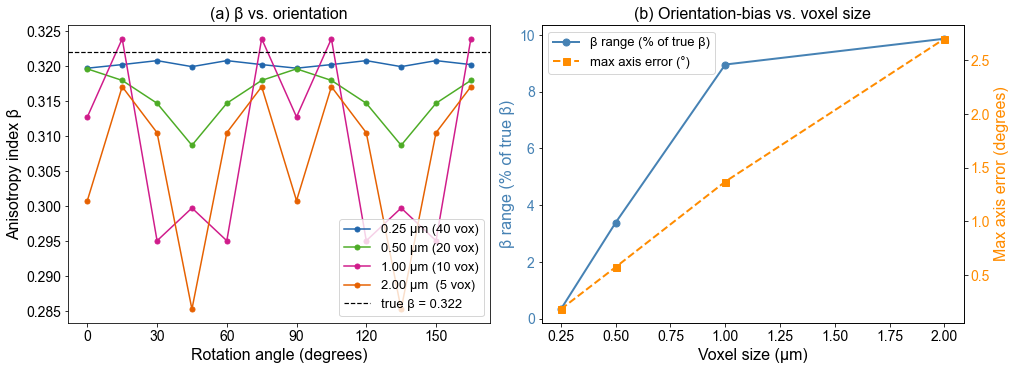

In [6]:
# ── Figure: 2×2 panels ────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size':       BASE_FONT,
    'axes.titlesize':  BASE_FONT - 2,
    'axes.labelsize':  BASE_FONT - 2,
    'xtick.labelsize': BASE_FONT - 4,
    'ytick.labelsize': BASE_FONT - 4,
    'legend.fontsize': BASE_FONT - 4,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# ── Panel A: β vs. rotation angle ────────────────────────────────────────────
ax = axes[0]
for vox, color, lbl in zip(VOXEL_SIZES, COLORS,
                            ['0.25 μm (40 vox)', '0.50 μm (20 vox)',
                             '1.00 μm (10 vox)', '2.00 μm  (5 vox)']):
    sub = df[df['voxel_size'] == vox].sort_values('angle_deg')
    ax.plot(sub['angle_deg'], sub['beta'], 'o-', ms=5, lw=1.5,
            color=color, label=lbl)
ax.axhline(TRUE_BETA, color='k', ls='--', lw=1.2, label=f'true β = {TRUE_BETA:.3f}')
ax.set_xlabel('Rotation angle (degrees)')
ax.set_ylabel('Anisotropy index β')
ax.set_title('(a) β vs. orientation')
ax.set_xticks(ANGLES[::2])
ax.legend(fontsize=BASE_FONT - 5, loc='lower right')

# ── Panel B: β range and max axis error vs. voxel size ───────────────────────
ax2 = axes[1]
beta_ranges = []
axis_maxs   = []
for vox in VOXEL_SIZES:
    sub = df[df['voxel_size'] == vox]
    beta_ranges.append(sub['beta'].max() - sub['beta'].min())
    axis_maxs.append(sub['axis_err'].max())

beta_pcts = [100 * r / TRUE_BETA for r in beta_ranges]

ax2.plot(VOXEL_SIZES, beta_pcts, 'o-', ms=7, lw=2, color='steelblue', label='β range (% of true β)')
ax2_r = ax2.twinx()
ax2_r.plot(VOXEL_SIZES, axis_maxs, 's--', ms=7, lw=2, color='darkorange', label='max axis error (°)')

ax2.set_xlabel('Voxel size (μm)')
ax2.set_ylabel('β range (% of true β)', color='steelblue')
ax2_r.set_ylabel('Max axis error (degrees)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_r.tick_params(axis='y', labelcolor='darkorange')
ax2.set_title('(b) Orientation-bias vs. voxel size')

# Shared legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=BASE_FONT - 5, loc='upper left')

save_path = os.path.join(RESULTS_DIR, 'orientation_bias.pdf')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()